In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("1776250375-P2-Healthcare Analytics for Doctor Visits (1).csv")

In [3]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [4]:
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [5]:
df.shape

(5190, 13)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   str    
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   str    
 9   freepoor    5190 non-null   str    
 10  freerepat   5190 non-null   str    
 11  nchronic    5190 non-null   str    
 12  lchronic    5190 non-null   str    
dtypes: float64(2), int64(5), str(6)
memory usage: 527.2 KB


In [7]:
#stastical inforamation of the dataset
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [8]:
#Checking the null values
df.isnull().sum()

Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

### Univariate Analysis: Gender Distribution

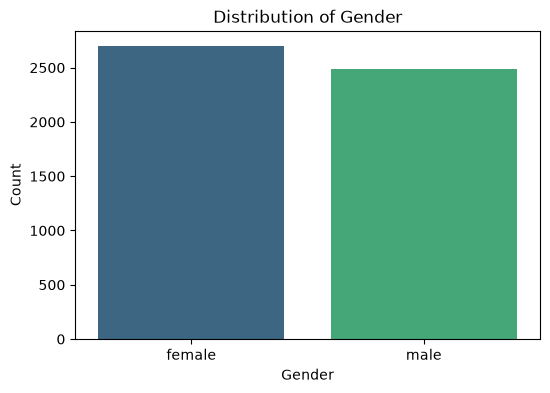

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette='viridis', hue='gender', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Univariate Analysis: Age Distribution

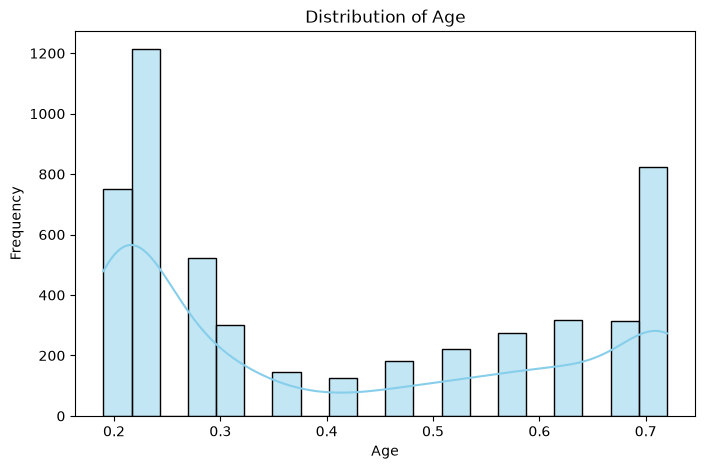

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Univariate Analysis: Doctor Visits Distribution

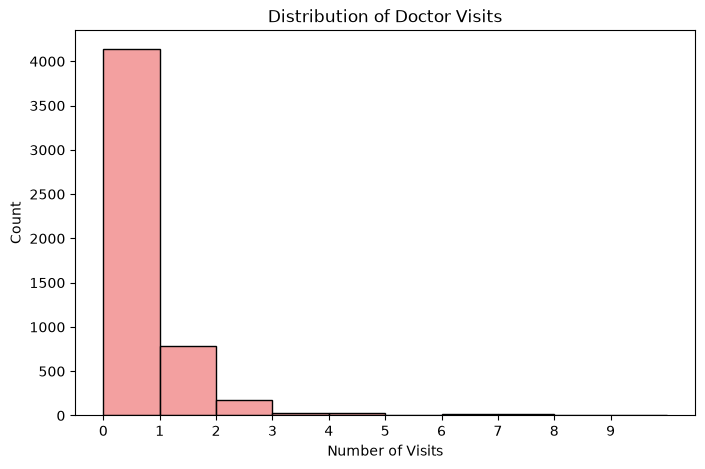

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['visits'], bins=range(int(df['visits'].max()) + 2), kde=False, color='lightcoral', stat='count')
plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.xticks(range(int(df['visits'].max()) + 1))
plt.show()

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


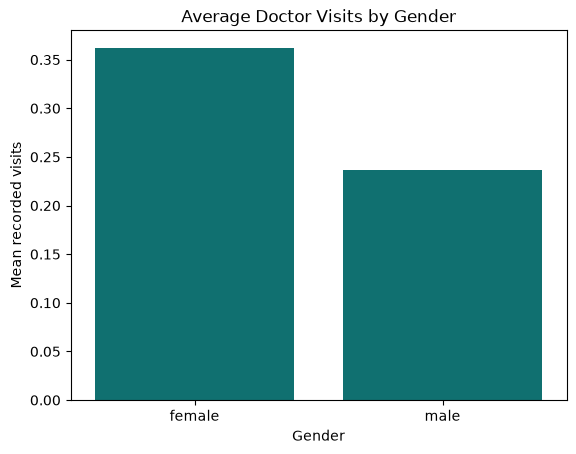

In [12]:
gender_analysis = (
    df.groupby("gender")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(gender_analysis)

sns.barplot(
    data=gender_analysis,
    x="gender",
    y="mean",
    color="teal"
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visits")
plt.show()

,illness,count,mean
0,0,1554,0.078507
1,1,1638,0.295482
2,2,946,0.403805
3,3,542,0.420664
4,4,274,0.576642
5,5,236,0.813559


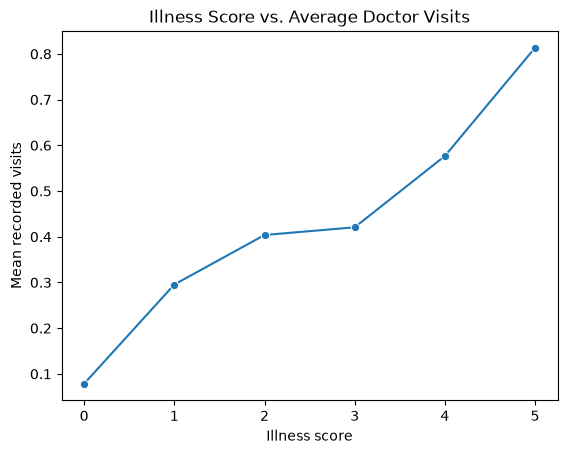

In [13]:
illness_analysis = (
    df.groupby("illness")["visits"]
      .agg(["count", "mean"])
      .reset_index()
)

display(illness_analysis)

sns.lineplot(
    data=illness_analysis,
    x="illness",
    y="mean",
    marker="o"
)

plt.title("Illness Score vs. Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Mean recorded visits")
plt.show()

### Multivariate Analysis: Visits by Gender

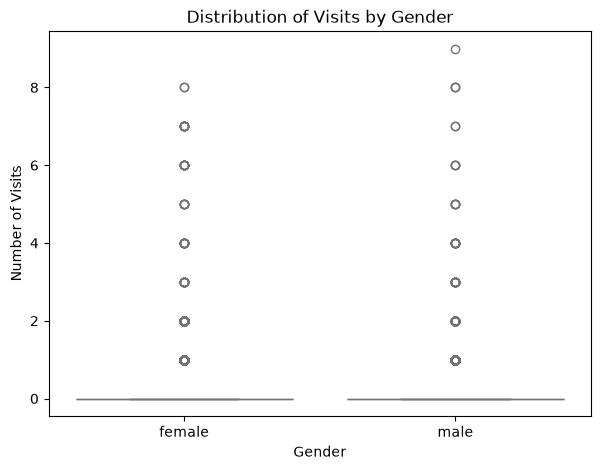

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='gender', y='visits', data=df, palette='pastel', hue='gender', legend=False)
plt.title('Distribution of Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Visits')
plt.show()

### Multivariate Analysis: Age, Visits, and Gender

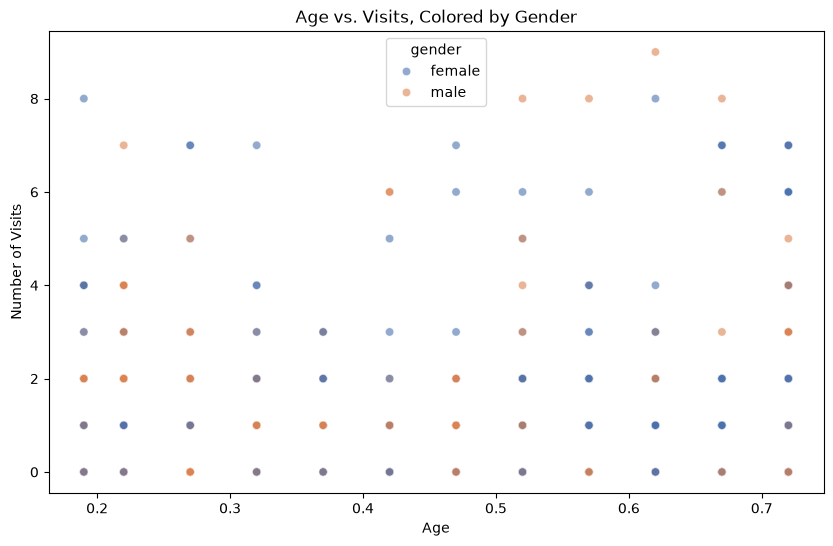

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='visits', hue='gender', data=df, palette='deep', alpha=0.6)
plt.title('Age vs. Visits, Colored by Gender')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.show()